In [2]:
import os
import zipfile
import pandas as pd
from google.colab import drive
import numpy as np
import tensorflow as tf
import random

seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

drive.mount('/content/drive')


path_zip_train = '/content/drive/MyDrive/MPA_Project/x_train.zip'
path_zip_test = '/content/drive/MyDrive/MPA_Project/x_test.zip'
path_csv_train = '/content/drive/MyDrive/MPA_Project/y_train_v2.csv'

dir_train = '/content/dataset/train/'
dir_test = '/content/dataset/test/'

os.makedirs(dir_train, exist_ok=True)
os.makedirs(dir_test, exist_ok=True)

# 3. Extrair os ficheiros ZIP
with zipfile.ZipFile(path_zip_train, 'r') as zip_ref:
    zip_ref.extractall(dir_train)

with zipfile.ZipFile(path_zip_test, 'r') as zip_ref:
    zip_ref.extractall(dir_test)


Mounted at /content/drive


In [3]:
# 1. Load the CSV file
df_train = pd.read_csv(path_csv_train)

# 2. Fix missing targets: Replace NaN values with 0 (Machine only class)
df_train['target'] = df_train['target'].fillna(0).astype(int)

# 3. Create the correct filename (adding 1 to the ID)
# Example: id 0 becomes "img_1.png"
df_train['filename'] = 'img_' + (df_train['id'] + 1).astype(str) + '.png'

# 4. Convert the target (class) to string
# This is important because Keras prefers categorical labels as strings for classification
df_train['target'] = df_train['target'].astype(str)

# Show first rows
print("\nPrepared training dataframe:")
display(df_train.head(20))


Prepared training dataframe:


,id,target,filename
0,0,0,img_1.png
1,1,1,img_2.png
2,2,0,img_3.png
3,3,2,img_4.png
4,4,2,img_5.png
5,5,1,img_6.png
6,6,3,img_7.png
7,7,2,img_8.png
8,8,2,img_9.png
9,9,3,img_10.png


In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Split the dataframe (Obrigatório para termos os 20% de teste local)
train_df, val_df = train_test_split(
    df_train, test_size=0.2, random_state=42, stratify=df_train['target']
)

batch_size = 32
img_height, img_width = 45, 51

print("Configuring the CLEAN ImageDataGenerators (Sem Data Augmentation)...")

# 2. Training generator LIMO (Apenas rescale, sem zoom/shift)
train_datagen_clean = ImageDataGenerator(rescale=1./255)

# 3. Validation generator (Apenas rescale)
val_datagen = ImageDataGenerator(rescale=1./255)

# 4. Create the Training flow
train_generator = train_datagen_clean.flow_from_dataframe(
    dataframe=train_df,
    directory=dir_train,
    x_col="filename",
    y_col="target",
    target_size=(img_height, img_width),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)

# 5. Create the Validation flow
validation_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=dir_train,
    x_col="filename",
    y_col="target",
    target_size=(img_height, img_width),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)

print(f"\nResumo: {train_generator.samples} imagens para treinar, {validation_generator.samples} para validar.")

Configuring the CLEAN ImageDataGenerators (Sem Data Augmentation)...
Found 7381 validated image filenames belonging to 4 classes.
Found 1846 validated image filenames belonging to 4 classes.

Resumo: 7381 imagens para treinar, 1846 para validar.


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import GlobalAveragePooling2D


print("Building the CNN V3: Wider & Regularized...")

# 1. Define the CNN Architecture
model = Sequential([
    # Block 1 (Filters doubled: 64)
    Conv2D(64, (3, 3), activation='relu', input_shape=(img_height, img_width, 1)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 2 (Filters doubled: 128)
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 3 (Filters doubled: 256)
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),

    # Dense Layers with L2 Regularization
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    # Output layer
    Dense(4, activation='softmax')
])

# 2. Compile with custom, slower Learning Rate
custom_adam = Adam(learning_rate=0.0005)

model.compile(optimizer=custom_adam,
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

# Display the massive new architecture
model.summary()

# 3. Callbacks (Increased patience because we are learning slower)
callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss', min_lr=1e-6)
]

print("\nStarting the V3 training process (This will be heavier!)...")

# 4. Train the model (Allowing up to 50 epochs, EarlyStopping will catch it)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=callbacks
)

print("\nV3 Training completed! Generate the plots to see the result.")

Building the CNN V3: Wider & Regularized...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 43, 49, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 43, 49, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 41, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 41, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 18, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 19, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           51

 Total params: 1,248,580 (4.76 MB)

 Trainable params: 1,246,020 (4.75 MB)

 Non-trainable params: 2,560 (10.00 KB)


Starting the V3 training process (This will be heavier!)...
Epoch 1/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.6017 - loss: 1.6494 - val_accuracy: 0.4101 - val_loss: 3.0044 - learning_rate: 5.0000e-04
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7637 - loss: 1.2558 - val_accuracy: 0.4377 - val_loss: 2.0468 - learning_rate: 5.0000e-04
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8381 - loss: 1.1055 - val_accuracy: 0.7270 - val_loss: 1.2126 - learning_rate: 5.0000e-04
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8828 - loss: 1.0069 - val_accuracy: 0.8359 - val_loss: 1.0308 - learning_rate: 5.0000e-04
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9129 - loss: 0.9202 - val_accuracy: 0.8678 - val_loss: 0.9487 - learning_rate: 5.0000e-04
Epoch 6/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9377 - loss: 0.8584 - val_accuracy: 0.8992 - val_loss: 0.8943 - learning_rate: 5.0000e

Generating training plots...


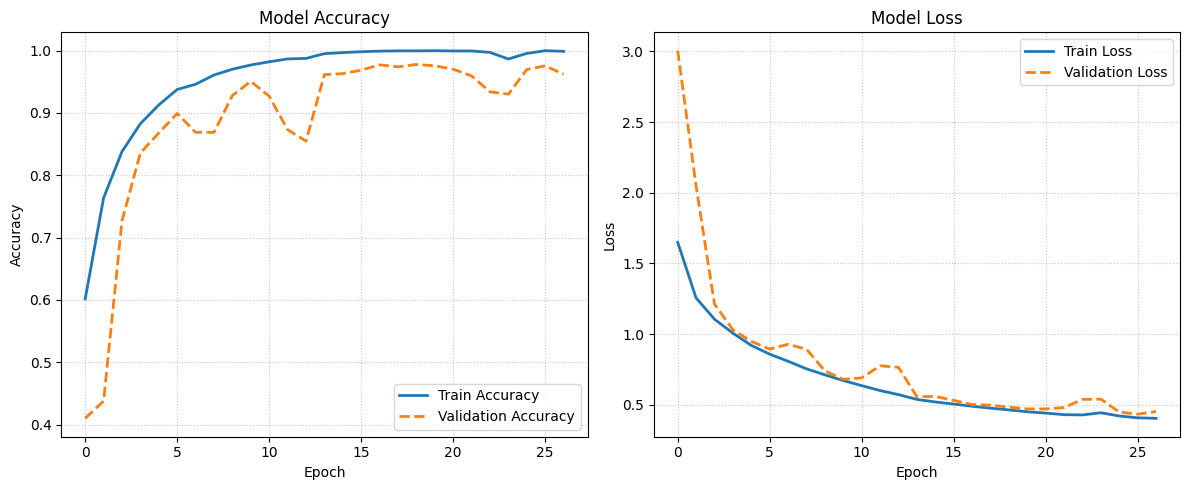

In [6]:
import matplotlib.pyplot as plt

print("Generating training plots...")

# Create a figure with two side-by-side plots
plt.figure(figsize=(12, 5))

# 1. Plot for accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

# 2. Plot for loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

In [7]:
import numpy as np

print("Preparing test data for the final predictions...")

# 1. Get all filenames from the test folder
test_filenames = os.listdir(dir_test)

print(test_filenames)
# 2. Create a temporary DataFrame
df_test = pd.DataFrame({'filename': test_filenames})

# 3. Test Generator (ONLY rescale, NO Data Augmentation!)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    directory=dir_test,
    x_col="filename",
    y_col=None,
    target_size=(img_height, img_width),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode=None,
    shuffle=False
)

print(f"\nRunning predictions on {len(test_filenames)} test images...")

# 4. Generate predictions
predictions = model.predict(test_generator)

# Convert probabilities (e.g., [0.1, 0.8, 0.05, 0.05]) into the winning class (e.g., Class 1)
predicted_classes = np.argmax(predictions, axis=1)

print("\nCreating the Kaggle submission file...")

# 5. Extract the correct ID from the filename
# Example: 'img_1.png' -> remove 'img_', remove '.png' -> '1' -> subtract 1 -> ID 0
ids = [int(f.replace('img_', '').replace('.png', '')) - 1 for f in test_filenames]

# 6. Build the final table
submission_df = pd.DataFrame({
    'id': ids,
    'target': predicted_classes
})

# 7. Sort by ID to match Kaggle's exact expectations
submission_df = submission_df.sort_values('id')

# 8. Save as a CSV file
file_path = '/content/kaggle_submission_v3.csv'
submission_df.to_csv(file_path, index=False)

print(f"\nDone! file is ready at: {file_path}")

Preparing test data for the final predictions...
['img_10719.png', 'img_10873.png', 'img_12766.png', 'img_9465.png', 'img_9632.png', 'img_9881.png', 'img_12230.png', 'img_11127.png', 'img_11596.png', 'img_9779.png', 'img_10036.png', 'img_10045.png', 'img_9621.png', 'img_11290.png', 'img_12629.png', 'img_12175.png', 'img_11567.png', 'img_12928.png', 'img_10448.png', 'img_9617.png', 'img_12974.png', 'img_10988.png', 'img_10359.png', 'img_12934.png', 'img_12005.png', 'img_10152.png', 'img_11774.png', 'img_12380.png', 'img_11304.png', 'img_10420.png', 'img_11721.png', 'img_10817.png', 'img_12657.png', 'img_9786.png', 'img_11106.png', 'img_11959.png', 'img_10384.png', 'img_12901.png', 'img_12238.png', 'img_11066.png', 'img_10299.png', 'img_11647.png', 'img_11392.png', 'img_12989.png', 'img_11825.png', 'img_13006.png', 'img_10599.png', 'img_9654.png', 'img_10565.png', 'img_9960.png', 'img_12180.png', 'img_11356.png', 'img_12031.png', 'img_12958.png', 'img_10123.png', 'img_10868.png', 'img_10

Found 1846 validated image filenames belonging to 4 classes.
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


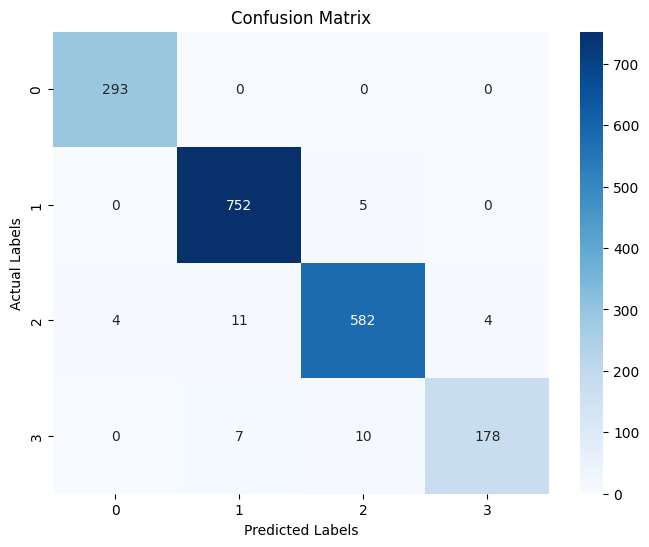


Classification Report (F1-Scores):
              precision    recall  f1-score   support

     Class 0       0.99      1.00      0.99       293
     Class 1       0.98      0.99      0.98       757
     Class 2       0.97      0.97      0.97       601
     Class 3       0.98      0.91      0.94       195

    accuracy                           0.98      1846
   macro avg       0.98      0.97      0.97      1846
weighted avg       0.98      0.98      0.98      1846



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Validation setinden gerçek etiketleri ve tahminleri al
# Validation generator'ı karıştırmadan (shuffle=False) tekrar tanımlamalıyız ki sonuçlar eşleşsin
val_generator_fixed = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=dir_train,
    x_col="filename",
    y_col="target",
    target_size=(img_height, img_width),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Y_pred = model.predict(val_generator_fixed)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator_fixed.classes

# 2. Confusion Matrix Oluştur
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1', '2', '3'],
            yticklabels=['0', '1', '2', '3'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()

# 3. F1-Score ve Diğer Metrikleri Yazdır
print("\nClassification Report (F1-Scores):")
print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3']))